# Inference 

In [1]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys
import skimage
import skimage.io
import skimage.transform
import skimage
import skimage.io
import tifffile

import time
import torch
import torch.hub
import torch.nn

from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion

## 1) Load data

(7386, 7388)


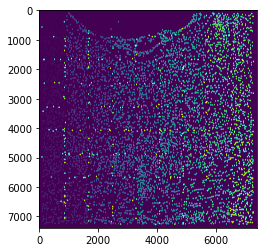

In [2]:
count_stat = pd.read_csv("./output/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_count_stat.csv", index_col=0)
count = pd.read_csv("./Sample_data/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26.csv", index_col=0)
count = count.loc[:, count_stat.columns.values]

image_file = "./output/Dataset_MERFISH//mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_pseuso_image_v2.pt"
image = torch.load(image_file)
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [3]:
transformation_file = "./Sample_data/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_v2.csv"
pd_meta = pd.read_table(transformation_file, index_col=0, sep=",")
pd_meta.loc[:, 'Centroid_X'] *= 4
pd_meta.loc[:, 'Centroid_Y'] *= 4
print(pd_meta.shape)
print(count.shape)

(5555, 170)
(5555, 161)


In [4]:
pd_meta

,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,Ace2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
2,e9d73818-5233-41aa-b387-25257543d9de,18,Female,Parenting,0.26,132.412808,588.180461,Inhibitory,I-17,0.000000,...,0.000000,0.000000,0.785172,0.000000,0.252832,0.000000,0.000000,0.000000,0.000000,0.301008
3,704470b6-2455-4e8d-be4c-6337b017efd0,18,Female,Parenting,0.26,137.852216,244.618301,Inhibitory,I-17,0.000000,...,0.053157,0.000000,0.954474,0.022710,0.551244,0.000000,0.000000,0.000000,0.029035,0.054919
4,16b60d1b-e1b9-40e3-bd99-848f2c03047a,18,Female,Parenting,0.26,149.792984,315.350523,Inhibitory,I-17,0.000000,...,0.043167,0.000000,1.025583,0.013712,0.781845,0.000000,0.000000,0.000000,0.029430,0.000000
5,f5346407-1501-407d-b981-445f46023b16,18,Female,Parenting,0.26,154.099004,369.059756,Inhibitory,I-17,0.000000,...,0.000000,0.000000,0.685039,0.000000,0.114975,0.000000,0.000000,0.000000,0.029108,0.000000
6,b1ab923f-d5fd-4eff-99d3-76bb333db9b2,18,Female,Parenting,0.26,162.245088,434.140557,Inhibitory,I-17,0.000000,...,3.289237,0.000000,0.662800,0.015281,0.000000,0.000000,0.000000,0.000000,0.027072,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5552,331a482f-2b97-46d0-999f-bddc91395d51,18,Female,Parenting,0.26,7158.664492,5665.132542,OD Mature 1,NaN,0.000000,...,0.013043,0.000000,0.000000,0.015949,0.000000,0.004345,0.019068,0.020962,0.007964,0.000000
5553,1dc07ac5-7713-4851-81e7-82190dd4ad81,18,Female,Parenting,0.26,7217.570824,5680.852131,OD Mature 1,NaN,0.000000,...,0.010604,0.012548,0.000000,0.019167,0.005378,0.000000,0.000000,0.031773,0.007725,0.000000
5554,b548b5c3-4286-4426-b95a-2afe715420f7,18,Female,Parenting,0.26,6735.179840,6463.448364,Inhibitory,I-1,0.825408,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031846
5555,2d19a0f3-2196-41ab-8ed7-486fca9db40b,18,Female,Parenting,0.26,6906.159372,6479.665867,Inhibitory,I-1,0.000000,...,0.000000,0.000000,0.215245,0.000000,0.051812,0.065958,0.074774,0.000000,0.001262,0.097569


In [5]:
# Split training and testing
np.random.seed(100)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.97), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 5388, #Testing: 167


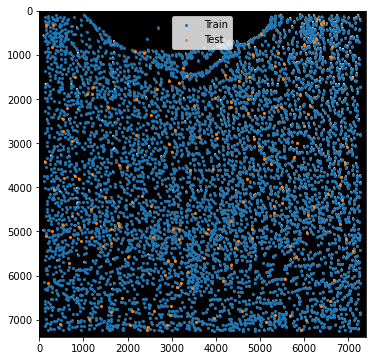

In [6]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm, cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Centroid_X"].values
coords_y = pd_meta.loc[training_indexes, "Centroid_Y"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Centroid_X"].values
coords_y = pd_meta.loc[testing_indexes, "Centroid_Y"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [7]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [8]:
count

,Ace2,Adora2a,Aldh1l1,Amigo2,Ano3,Aqp4,Ar,Arhgap36,Avpr1a,Avpr2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
2,0.000000,0.000000,0.261040,0.000000,0.733287,0.000000,0.492338,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.377235,0.000000,0.252484,0.000000,0.000000,0.000000,0.000000,0.125869
3,0.000000,0.379820,0.000000,0.000000,0.432128,0.000000,0.284200,0.256115,0.000000,0.000000,...,0.020482,0.000000,0.436216,0.008250,0.491798,0.000000,0.000000,0.000000,0.025519,0.025574
4,0.000000,0.000000,0.000000,0.640248,0.664014,0.000000,0.481304,0.000000,0.000000,0.000000,...,0.016713,0.000000,0.459478,0.005003,0.647039,0.000000,0.000000,0.000000,0.025862,0.000000
5,0.000000,0.169545,0.000000,0.479686,0.816503,0.000000,0.523833,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.339659,0.000000,0.121905,0.000000,0.000000,0.000000,0.025583,0.000000
6,0.000000,0.737422,0.149935,0.000000,0.686871,0.280726,0.000000,0.352298,0.293367,0.000000,...,0.575833,0.000000,0.331010,0.005572,0.000000,0.000000,0.000000,0.000000,0.023817,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5552,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.159131,0.000000,0.000000,...,0.005125,0.000000,0.000000,0.005813,0.000000,0.001794,0.005421,0.013084,0.007073,0.000000
5553,0.000000,0.000000,0.000000,0.000000,0.000000,0.167039,0.000000,0.000000,0.000000,0.000000,...,0.004172,0.009079,0.000000,0.006975,0.006007,0.000000,0.000000,0.019728,0.006861,0.000000
5554,0.180497,0.000000,0.000000,0.259918,0.166408,0.000000,0.619536,0.235578,0.000000,0.262189,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014996
5555,0.000000,0.000000,0.146824,0.193578,0.000000,0.139807,0.384860,0.175451,0.287281,0.000000,...,0.000000,0.000000,0.126900,0.000000,0.056582,0.026429,0.020696,0.000000,0.001124,0.044532


In [9]:
PATCH_SIZE = 512

In [10]:
hue_order = list(set(pd_meta['Cell_class'].values))
hue_order.sort()
hue_order = np.array(hue_order)
print(hue_order)

['Ambiguous' 'Astrocyte' 'Endothelial 1' 'Endothelial 2' 'Endothelial 3'
 'Ependymal' 'Excitatory' 'Inhibitory' 'Microglia' 'OD Immature 1'
 'OD Immature 2' 'OD Mature 1' 'OD Mature 2' 'OD Mature 3' 'OD Mature 4'
 'Pericytes']


In [11]:
n_genes_for_image = 3
gene_names_for_image = count_stat.columns.values[np.argsort(count_stat.loc['std', :].values)[::-1][:3]]
pseudo_image = torch.load("./output/Dataset_MERFISH/2_pseudo_image_pc_v2.pt")

## 2) Check data loader

In [13]:
# from utils_data import Dataset
# from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data

def normalize(image):
    return image
    
def augmentor(image, label=None):
    """Do image shape and color augmentation.
    
    Args:
        image: [h, w, c], float
    """
    n_channels = image.shape[2]
    
    # Shape augmentation
    if np.random.uniform(0, 1) < 0.8:
        # Projective transform
        scale = np.random.uniform(0.9, 1.1)
        aspect_ratio = np.random.uniform(0.9, 1.1)
        rotation = np.random.uniform(-0.1, 0.1)
        translationX = np.random.uniform(-10, 10)
        translationY = np.random.uniform(-10, 10)
        g = np.random.uniform(-0.001, 0.001)
        h = np.random.uniform(-0.001, 0.001)

        matrix = np.array([[math.cos(rotation) * scale * aspect_ratio, -math.sin(rotation), translationX],
                          [math.sin(rotation), math.cos(rotation) * scale / aspect_ratio, translationY],
                          [g, h, 1]])
        tform = skimage.transform.ProjectiveTransform(matrix=matrix)
        image_aug = np.zeros_like(image, dtype=np.float)
        for ch in range(n_channels):
            image_aug[..., ch] = skimage.transform.warp(image[..., ch], tform, preserve_range=True)
        
        image = image_aug
        
        if label is not None:
            label_aug = np.zeros_like(label, dtype=np.int)
            label_aug = skimage.transform.warp(label, tform, preserve_range=True, order=0)
            label = label_aug
    if np.random.uniform(0, 1) < 0.5:
        # Do 50% vertical flipping
        image = image[::-1, :, :]
        
        if label is not None:
            label = label[::-1, :]
    if np.random.uniform(0, 1) < 0.5:
        # Do 50% horizontal flipping
        image = image[:, ::-1, :]
        
        if label is not None:
            label = label[:, ::-1]
            
    '''
    # Color augmentation
    # 1) add a global shifting for all channels
    image = image + np.random.randn(1)[0] * 0.1

    # 2) add a shifting & variance for each channel
    for ch in range(n_channels):
        image[:, :, ch] = image[:, :, ch] * np.clip(np.random.randn(1)[0] * 0.2 + 1, 0.8, 1.2) + np.random.randn(1)[0] * 0.3
    '''
        
    if label is not None:
        return image, label
    else:
        return image
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    row_end = row_start + patch_size
    col_end = col_start + patch_size
    _image = image[max(row_start, 0):row_end, max(col_start, 0):col_end, ...]
    if len(image.shape) == 2:
        image_temp = np.zeros((patch_size, patch_size))
    else:
        image_temp = np.zeros((patch_size, patch_size, image.shape[2]))
    
    if _image.shape[0] == 0 or _image.shape[1] == 0:
        print(coords, "0 shape detected")
        return image_temp
    if _image.shape[0] == patch_size and _image.shape[1] == patch_size:
        return _image
    if row_start < 0:
        _row_start = -row_start
    else:
        _row_start = 0
    if col_start < 0:
        _col_start = -col_start
    else:
        _col_start = 0
    image_temp[_row_start:_row_start + _image.shape[0], _col_start:_col_start + _image.shape[1], ...] = _image
    return image_temp
            
    
    # return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Centroid_X"], self.meta_df.loc[indexes, "Centroid_Y"]], 
                                PATCH_SIZE) 
        if self.augmentation:
            image_1, image_0 = augmentor(image[..., 1:], image[..., 0])  # Use label augmentation to preserve range & order 0
            image_temp = np.zeros([PATCH_SIZE, PATCH_SIZE, n_genes_for_image + 1])
            image_temp[..., 0] = image_0
            image_temp[..., 1:] = image_1
        else:
            image_temp = normalize(image)
            
        '''
        ######## For MERFISH pseudo image
        image_temp = np.zeros([PATCH_SIZE, PATCH_SIZE, self.count_df.shape[1] + 1])
        
        cell_ids = np.unique(image)
        for cell_id in cell_ids:
            if cell_id >= 2:
                # 0st channel: Cell category; 0 is background
                image_temp[image == cell_id, 0] = np.argmax(hue_order == self.meta_df.loc[cell_id, "Cell_class"]) + 1

                # rest channels: Gene expression
                image_temp[image == cell_id, 1:] = self.count_df.loc[cell_id, :].values
        
        ######## End for MERFISH pseudo image
        '''
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image_temp, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

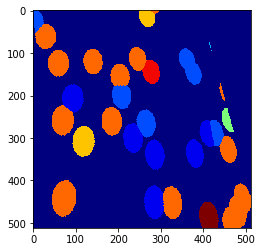

[ 0.  1.  2.  3.  5.  7.  8.  9. 10.]
tensor([1062])


In [14]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, pseudo_image, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
# while True:
for x, y in train_loader:
    plt.imshow(np.transpose(x['image'][0].numpy(), (1, 2, 0))[..., 0], cmap='jet', interpolation='nearest')
    plt.show()
    print(np.unique(np.transpose(x['image'][0].numpy(), (1, 2, 0))[..., 0]))
    print(y)
    break

In [15]:
np.unique(pseudo_image[..., 0])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

## 3) Create network

In [19]:
from torch.nn.modules import MSELoss
from utils_eval import NCESoftmaxLoss, NCECriterion


device = torch.device("cuda:0")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 50
imagenet = 'resnet101'

# NCE parameters
nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01   # ori 0.01
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, pseudo_image, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, pseudo_image, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, n_image_channels=n_genes_for_image+10, 
               n_embedding_input=len(hue_order)+1, n_embedding_output=10, 
               imagenet=imagenet, genenet=[100, 50]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

Using cache found in /home2/swan15/.cache/torch/hub/pytorch_vision_v0.6.0


In [5]:
model_dir = "./models/Dataset_MERFISH"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [7]:
"""TO LOAD:"""
model_file = os.path.join(model_dir, "epoch_best.pt") 
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

=> loading checkpoint './models/Dataset_MERFISH/epoch_best.pt'


## 4) Validate and save result

In [24]:
test_set = Dataset(indexes_all, pseudo_image, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

In [25]:
model.eval()

with torch.no_grad():
    for idx, (data, index) in enumerate(test_loader):
        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])

In [26]:
feat_images.shape

(5555, 50)

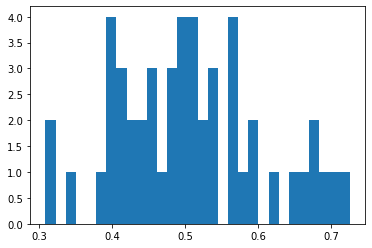

In [27]:
# Normalize & calculate correlation
from scipy.stats import spearmanr

feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
corr = []
for i in range(feat_images.shape[1]):
    corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
plt.hist(corr, bins=30)
plt.show()

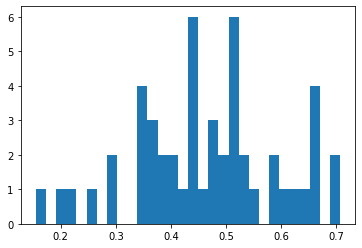

In [28]:
# Normalize & calculate correlation in testing set
from scipy.stats import spearmanr

_feat_images = np.array([feat_images[_, :] for _, index in enumerate(indexes_all) if index in testing_indexes])
_feat_genes = np.array([feat_genes[_, :] for _, index in enumerate(indexes_all) if index in testing_indexes])
corr = []
for i in range(_feat_images.shape[1]):
    corr.append(spearmanr(_feat_images[:, i], _feat_genes[:, i]).correlation)
plt.hist(corr, bins=30)
plt.show()

In [29]:
# Save result
torch.save([feat_images, feat_genes], "./output/Dataset_MERFISH/3_IGC_mouse_hypothalamus_all_indexes_features.pt")

# Session Info

In [33]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2021.5.30
chardet==3.0.4
charset-normalizer==2.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
fastcluster==1.2.4
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==3.2
image-registration==0.2.4
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel